In [737]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=4382 sha256=ddef975118f968c890056b907aac4e7780b7c74e28e64f8ba5615caafc834a5e
  Stored in directory: /tmp/pip-ephem-wheel-cache-krlupvqu/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [1107]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter, OrderedDict
from tqdm.notebook import tqdm
from sklearn.feature_selection import mutual_info_classif
from matplotlib.patches import Patch
import matplotlib as mpl
from scipy.stats import spearmanr
import seaborn as sns
from scipy.stats import fisher_exact
from itertools import combinations
import joypy
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.ticker as mtick
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.modeling.analysis import *
from winogender_contextuality.config import * 

# Constants

In [740]:
case_index = {
    "$NOM_PRONOUN": 0,
    "$POSS_PRONOUN": 1,
    "$ACC_PRONOUN": 2
}

In [741]:
case_pronouns = {
    "$NOM_PRONOUN": ['he', 'she'],
    "$POSS_PRONOUN": ['his', 'her'],
    "$ACC_PRONOUN": ['him', 'her']
}

In [742]:
gender_pronouns = {
    'm': ['he', 'him', 'his'],
    'f': ['she', 'her', 'her']
}

# Functions

In [743]:
def clip_errs(lower, upper, min_val=0.0):
    lower = np.maximum(lower, min_val)
    upper = np.maximum(upper, min_val)
    return np.vstack([lower, upper])

In [744]:
def primed_completion_differences_null(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 180,
                                  CIs: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []
    ci_list = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        null_1 = get_sent_order(["null_0", 0], all_index_data)
        null_2 = get_sent_order(["null_1", 0], all_index_data)


        # Probabilities
        p_null_1 = prob_func(null_1)
        p_null_2 = prob_func(null_2)

        try: 
            differences.append((p_null_1, p_null_2))
        except ValueError:
            print(null_1, null_2)

        if CIs:
            if mode == 'internal':
                raise ValueError("No CIs around internal logits.")
                
            ci_null_1 = get_generation_cis(null_1)
            ci_null_2 = get_generation_cis(null_2)
    
            try: 
                ci_list.append((ci_null_1, ci_null_2))
            except ValueError:
                print(ci_null_1, ci_null_2)

    if CIs:
        return differences, ci_list
    else:
        return differences

In [908]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 180,
                                  CIs: bool = False,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []
    ci_list = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        unprimed_1 = get_sent_order([0, 1], get_single_sentences(all_index_data))
        unprimed_2 = get_sent_order([1, 0], get_single_sentences(all_index_data))

        primed_m1 = get_sent_order([0, 1], get_filled_pnoun(0, all_index_data))
        primed_f1 = get_sent_order([0, 1], get_filled_pnoun(1, all_index_data))
        primed_m2 = get_sent_order([1, 0], get_filled_pnoun(0, all_index_data))
        primed_f2 = get_sent_order([1, 0], get_filled_pnoun(1, all_index_data))


        # Probabilities
        p_unprimed_1 = prob_func(unprimed_1)
        p_unprimed_2 = prob_func(unprimed_2)

        p_primed_m1 = prob_func(primed_m1)
        p_primed_f1 = prob_func(primed_f1)
        p_primed_m2 = prob_func(primed_m2)
        p_primed_f2 = prob_func(primed_f2)

        tup1 = (p_unprimed_1, p_primed_m1, p_primed_f1)
        tup2 = (p_unprimed_2, p_primed_m2, p_primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

        if CIs:
            if mode == 'internal':
                raise ValueError("No CIs around internal logits.")
                
            ci_unprimed_1 = get_generation_cis(unprimed_1)
            ci_unprimed_2 = get_generation_cis(unprimed_2)
    
            ci_primed_m1 = get_generation_cis(primed_m1)
            ci_primed_f1 = get_generation_cis(primed_f1)
            ci_primed_m2 = get_generation_cis(primed_m2)
            ci_primed_f2 = get_generation_cis(primed_f2)
    
            ci_tup1 = (ci_unprimed_1, ci_primed_m1, ci_primed_f1)
            ci_tup2 = (ci_unprimed_2, ci_primed_m2, ci_primed_f2)
    
            try: 
                ci_list.append(ci_tup1)
                ci_list.append(ci_tup2)
            except ValueError:
                print(ci_tup1, ci_tup2)
            

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    if CIs:
        return differences, ci_list
    else:
        return differences

In [909]:
def create_feature_table(index: int, 
                         data: list[Measurement] | list[dict],
                         features_df: pd.DataFrame):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for a *pair of sentences* using measurements provided. 

    ONLY OUTPUTS PRIMED INSTANCES.

    :param ratio: whether to exclude instances where target role has no ratio.

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(index,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(index,data, filter_none=True))

    forward_index = 2 * index
    reverse_index = 2 * index + 1

    forward_occ = features_df["role"][forward_index]
    reverse_occ = features_df["role"][reverse_index]

    forward_role = features_df["role_type"][forward_index]
    reverse_role = features_df["role_type"][reverse_index]

    forward_case = case_index[features_df["pronoun_type"][forward_index]]
    reverse_case = case_index[features_df["pronoun_type"][reverse_index]]

    forward_stereo = features_df["stereotype"][forward_index]
    reverse_stereo = features_df["stereotype"][reverse_index]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
        'Measurement': fwd_measurement_list + bwd_measurement_list, 
        'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
        'Role_Type': [forward_role] * len(fwd_list) + [reverse_role]*len(bwd_list),
        'Case': [forward_case] * len(fwd_list) + [reverse_case]*len(bwd_list),
        'Stereotype': [forward_stereo] * len(fwd_list) + [reverse_stereo]*len(bwd_list),
        'Prime': fwd_prime_list + bwd_prime_list,
        'Order': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"].isin(gender_pronouns['f'])).astype(int)
    measurements_df["y_role_type"] = (measurements_df["Role_Type"] == "occupation").astype(int)
    measurements_df["y_prime"] = (measurements_df["Prime"].isin(gender_pronouns['f'])).astype(int)
    measurements_df["y_stereo"] = measurements_df["Stereotype"]
    measurements_df["y_order"] = (measurements_df["Order"]).astype(int)
    measurements_df["y_primed"] = [i != 'None' for i in measurements_df["Prime"]]
    measurements_df["y_case"] = (measurements_df["Case"]).astype(int)

    return measurements_df
    
    

In [747]:
def get_mi_arr(data: list[dict] | list[Measurement],
               features_df: pd.DataFrame,
               role_type: bool = True,
               prime: bool = True,
               primed_status: bool = True,
               stereo: bool = True,
               case: bool = True,
               order: bool = True,
               include_unprimed = True, 
               include_primed = True,
               max_index: int = 360):
    """
    :param ratio: True removes any indices for whom
    """

    indices = []
    MIs = []

    for idx in tqdm(range(max_index)):
        
        df = create_feature_table(idx, data, features_df)

        if stereo:
            # If measuring stereotype dependence, drop instances without stereotype collected
            df = df[~np.isnan(df["y_stereo"])]

        if not include_unprimed:
            df = df[df["y_primed"]]

        if not include_primed:
            df = df[~df["y_primed"]]
            

        disc_columns = []
        cont_columns = []
        if role:
            disc_columns.append("y_role_type")
        if prime:
            disc_columns.append("y_prime")
        if primed_status:
            disc_columns.append("y_primed")
        if order: 
            disc_columns.append("y_order")
        if case:
            disc_columns.append("y_case")
        if stereo:
            cont_columns.append("y_stereo")
        
            
        
        y = df["X"].to_numpy()

        try:
            mi = []
            if len(disc_columns) > 0:
                X_disc = df[disc_columns].to_numpy()
                mi_disc = mutual_info_classif(X_disc, y, discrete_features=True)
                mi.extend(mi_disc)
            if len(cont_columns):
                X_cont = df[cont_columns].to_numpy()
                mi_cont = mutual_info_classif(X_cont, y, discrete_features=False)
                mi.extend(mi_cont)
            MIs.append(mi)
            indices.append(idx)
        except ValueError:
            pass
            
    MI_arr = np.array(MIs)
    all_columns = disc_columns + cont_columns

    return indices, all_columns, MI_arr

In [748]:
def get_mi_df(data: list[dict] | list[Measurement],
              features_df: pd.DataFrame,
              role_type: bool = True,
              prime: bool = True,
              primed_status: bool = True,
              stereo: bool = True,
              case: bool = True,
              order: bool = True,
              include_unprimed = True, 
              include_primed = True,
              max_index: int = 360):
    """
    :param ratio: True removes any indices for whom
    """

    indices = []
    MIs = []

    for idx in tqdm(range(max_index)):
        
        df = create_feature_table(idx, data, features_df)

        if stereo:
            # If measuring stereotype dependence, drop instances without stereotype collected
            df = df[~np.isnan(df["y_stereo"])]

        if not include_unprimed:
            df = df[df["y_primed"]]

        if not include_primed:
            df = df[~df["y_primed"]]
            

        disc_columns = []
        cont_columns = []
        if role:
            disc_columns.append("y_role_type")
        if prime:
            disc_columns.append("y_prime")
        if primed_status:
            disc_columns.append("y_primed")
        if order: 
            disc_columns.append("y_order")
        if case:
            disc_columns.append("y_case")
        if stereo:
            cont_columns.append("y_stereo")
        
            
        
        y = df["X"].to_numpy()

        try:
            mi = []
            if len(disc_columns) > 0:
                X_disc = df[disc_columns].to_numpy()
                mi_disc = mutual_info_classif(X_disc, y, discrete_features=True)
                mi.extend(mi_disc)
            if len(cont_columns):
                X_cont = df[cont_columns].to_numpy()
                mi_cont = mutual_info_classif(X_cont, y, discrete_features=False)
                mi.extend(mi_cont)
            MIs.append(mi)
            indices.append(idx)
        except ValueError:
            pass
            
    MI_arr = np.array(MIs)
    all_columns = disc_columns + cont_columns

    out_df = pd.DataFrame(MI_arr, columns=all_columns, index=indices)

    return out_df

In [749]:
def get_contextuality_table(
        model_measurements: list[dict],
        default_pronoun: int = 1,  # 0 for male, 1 for female
        max_index: int = 360
) -> pd.DataFrame:
    indices = []

    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []

    for idx in tqdm(range(max_index)):

        try:

            # Internal
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')

            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')

            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')



        except Exception as e:
            logger.error(f"Error calculating degree of contextuality for index {idx}: {e}")
            continue

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df


In [750]:
def get_generation_counts(measurements: list[Measurement] | list[dict]) -> np.ndarray:
    """
    Returns empirical generation frequencies from a list of
     Measurements (or equivalent dictionaries).

    :param measurements: list of Measurement objects (or equivelant dictionaries)
    :return: array of probabilities
    """
    # pronoun set is determined by the first measurement
    try:
        pnouns = measurements[0]['context']['pronouns_2']
    except Exception as e:
        logger.debug(f"Likely no measurements found. Exception raised: {e}")
        return np.nan

    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generated_pnouns = []
    for m in measurements:
        try:
            generated_pnouns.append(m['measurement']['BLANK'])
        except Exception as e:
            logger.debug(f"Exception {e} raised for item {m}")
            pass
    generation_counter = Counter(generated_pnouns)
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))

    return np.array(list(generation_counter_clean.values())), num_valid_measurements

In [751]:
def primed_completion_difference_counts(data: list[Measurement],
                                  mode: str = 'generation',
                                  max_index: int = 180):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        raise NotYetImplementedError 
    elif mode == 'generation':
        prob_func = get_generation_counts
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        unprimed_1 = get_sent_order([0, 1], get_single_sentences(all_index_data))
        unprimed_2 = get_sent_order([1, 0], get_single_sentences(all_index_data))

        primed_m1 = get_sent_order([0, 1], get_filled_pnoun(0, all_index_data))
        primed_f1 = get_sent_order([0, 1], get_filled_pnoun(1, all_index_data))
        primed_m2 = get_sent_order([1, 0], get_filled_pnoun(0, all_index_data))
        primed_f2 = get_sent_order([1, 0], get_filled_pnoun(1, all_index_data))


        # Probabilities
        p_unprimed_1 = prob_func(unprimed_1)
        p_unprimed_2 = prob_func(unprimed_2)

        p_primed_m1 = prob_func(primed_m1)
        p_primed_f1 = prob_func(primed_f1)
        p_primed_m2 = prob_func(primed_m2)
        p_primed_f2 = prob_func(primed_f2)

        tup1 = (p_unprimed_1, p_primed_m1, p_primed_f1)
        tup2 = (p_unprimed_2, p_primed_m2, p_primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    return differences

In [752]:
def primed_completion_difference_counts_null(data: list[Measurement],
                                  mode: str = 'generation',
                                  max_index: int = 360):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        raise NotYetImplementedError
    elif mode == 'generation':
        prob_func = get_generation_counts
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        null_1 = get_sent_order(["null_0", 0], all_index_data)
        null_2 = get_sent_order(["null_1", 0], all_index_data)


        # Probabilities
        p_null_1 = prob_func(null_1)
        p_null_2 = prob_func(null_2)

        try: 
            differences.append((p_null_1, p_null_2))
        except ValueError:
            print(null_1, null_2)

    else:
        return differences

In [753]:
def calc_deviance(k,n,p_x,p_null):
    d_x = k*np.log(p_x) + (n - k) * np.log(1 - p_x)
    d_null = k*np.log(p_null) + (n - k) * np.log(1 - p_null)
    d = 2 * (d_x - d_null)
    return d

In [754]:
def get_deviances(count_tuples):

    deviances = []
    
    for triple in count_tuples:

        try:
            unprimed_counts, unprimed_total = triple[0]
            masc_counts, masc_total = triple[1]
            fem_counts, fem_total = triple[2]

            unprimed_prob = (unprimed_counts[1] + 0.5)/(unprimed_total + 1)
            masc_prob = (masc_counts[1] + 0.5)/(masc_total + 1)
            fem_prob = (fem_counts[1] + 0.5)/(fem_total + 1)
        
            masc_deviance = calc_deviance(masc_counts[1], masc_total, masc_prob, unprimed_prob)
            fem_deviance = calc_deviance(fem_counts[1], fem_total, fem_prob, unprimed_prob)
            
            deviances.append((masc_deviance, fem_deviance))
            
        except Exception as e:
            print(f"Error calculating deviance: {e}")
            pass
            
    num_captured = len(deviances)

    return np.sum(np.array(deviances), axis=0)/num_captured

In [755]:
def bernoulli_kl(p_x, p_null):
    kl = p_x * np.log2(p_x / p_null) + (1 - p_x) * np.log2((1 - p_x)/(1 - p_null))
    return kl

In [756]:
def get_model_divergences(count_tuples,
                         eps = 1e-12):

    divergences = []

    for triple in count_tuples:

        try:
            unprimed_counts, unprimed_total = triple[0]
            masc_counts, masc_total = triple[1]
            fem_counts, fem_total = triple[2]

            unprimed_prob = (unprimed_counts[1] + 0.5)/(unprimed_total + 1)
            masc_prob = (masc_counts[1] + 0.5)/(masc_total + 1)
            fem_prob = (fem_counts[1] + 0.5)/(fem_total + 1)

            masc_kl = bernoulli_kl(masc_prob, unprimed_prob)
            fem_kl = bernoulli_kl(fem_prob, unprimed_prob)

            divergences.append([masc_kl, fem_kl])

        except Exception as e:
            print(f"Error calculationg divergences: {e}")
            pass

    return np.array(divergences)

In [757]:
def get_null_divergences(count_tuples,
                         null_tuples,
                         eps = 1e-12):

    divergences = []


    for idx in range(len(count_tuples)):

        try:
            unprimed_counts, unprimed_total = count_tuples[idx][0]
            masc_counts, masc_total = count_tuples[idx][1]
            fem_counts, fem_total = count_tuples[idx][2]
            null1_counts, null1_total = null_tuples[idx][0]
            null2_counts, null2_total = null_tuples[idx][1]
        

            unprimed_prob = (unprimed_counts[1] + 0.5)/(unprimed_total + 1)
            masc_prob = (masc_counts[1] + 0.5)/(masc_total + 1)
            fem_prob = (fem_counts[1] + 0.5)/(fem_total + 1)
            null1_prob = (null1_counts[1] + 0.5)/(null1_total + 1)
            null2_prob = (null2_counts[1] + 0.5)/(null2_total + 1)

            masc_kl = bernoulli_kl(masc_prob, unprimed_prob)
            fem_kl = bernoulli_kl(fem_prob, unprimed_prob)
            null1_kl = bernoulli_kl(null1_prob, unprimed_prob)
            null2_kl = bernoulli_kl(null2_prob, unprimed_prob)

            divergences.append([masc_kl, fem_kl, null1_prob, null2_prob])

        except Exception as e:
            print(f"Error calculating divergences: {e}")
            pass
        

    return np.array(divergences)

In [758]:
# DELETE WHEN RERUNNING
def get_generation_details(measurements: list[Measurement] | list[dict]) -> np.ndarray:
    """
    Returns successes and total number of measurements from each trial.

    :param measurements: list of Measurement objects (or equivelant dictionaries)
    :return: array of probabilities
    """
    # pronoun set is determined by the first measurement
    try:
        pnouns = measurements[0]['context']['pronouns_2']
    except Exception as e:
        logger.debug(f"Likely no measurements found. Exception raised: {e}")
        return np.nan

    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generated_pnouns = []
    for m in measurements:
        try:
            generated_pnouns.append(m['measurement']['BLANK'])
        except Exception as e:
            logger.debug(f"Exception {e} raised for item {m}")
            pass
    generation_counter = Counter(generated_pnouns)
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))
    return generation_counter_clean, num_valid_measurements

# Loading Data

## Raw WinoPron Templates

In [759]:
raw_templates = pd.read_csv(RAW_DATA_DIR/"new_templates.tsv", sep="\t")

## Stereotypes Dataset

In [760]:
stereo = pd.read_csv("../occupation_english_means_final.csv")

## WinoPron T=0.5

In [761]:
gpt_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5_wp_k40.ndjson")
max_gpt = max([x["index"] for x in gpt_wp])
f"{len(gpt_wp)} Measuremenents"

'579200 Measuremenents'

In [762]:
phi_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_phi-4_0.5_wp_k40.ndjson")
max_phi = max([x["index"] for x in phi_wp])
f"{len(phi_wp)} Measuremenents"

'507354 Measuremenents'

In [763]:
gemma_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gemma-3-12b-it_0.5_wp_k40.ndjson")
max_gemma = max([x["index"] for x in gemma_wp])
f"{len(gemma_wp)} Measuremenents"

'426124 Measuremenents'

In [764]:
llama1b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1331141225.ndjson")
max_llama1b = max([x["index"] for x in llama1b_wp])
f"{len(llama1b_wp)} Measuremenents"

'1158400 Measuremenents'

In [765]:
llama8b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.1-8B-Instruct_0.5_wp_k40.ndjson")
max_llama8b = max([x["index"] for x in llama8b_wp])
f"{len(llama8b_wp)} Measuremenents"

'289600 Measuremenents'

In [766]:
qwen_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen2.5-7B-Instruct_0.5_wp_k40.ndjson")
max_qwen = max([x["index"] for x in qwen_wp])
f"{len(qwen_wp)} Measuremenents"

'388000 Measuremenents'

In [1033]:
winopron_results_05 = [gpt_wp, phi_wp, gemma_wp,  llama8b_wp, qwen_wp] #llama1b_wp,

In [1034]:
model_names = ['gpt', 'phi', 'gemma',  'llama8b', 'qwen'] #,'llama1b',

## WinoPron Null

## Creating a list of all sentences

In [769]:
winopron_pairs = pd.read_csv(INTERIM_DATA_DIR/"winopron_pairs.tsv", sep="\t")
winopron_pairs.head()

,template_1,differences_1,case_1,referent_1,template_2,differences_2,case_2,referent_2
0,The technician told the customer that BLANK co...,"['he', 'she']",$NOM_PRONOUN,customer,The technician told the customer that BLANK ha...,"['he', 'she']",$NOM_PRONOUN,technician
1,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,customer,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,technician
2,The customer told the technician that BLANK fr...,"['his', 'her']",$POSS_PRONOUN,customer,The customer told the technician that BLANK ch...,"['his', 'her']",$POSS_PRONOUN,technician
3,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,taxpayer,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,accountant
4,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,taxpayer,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,accountant


In [770]:
all_sentences_wp = pd.DataFrame()
all_templates = []
all_pnouns = []
all_referents = []
all_cases = []
for idx in winopron_pairs.index:
    for n in [1,2]:
        all_templates.append(winopron_pairs[f"template_{n}"][idx])
        all_pnouns.append(winopron_pairs[f"differences_{n}"][idx])
        all_referents.append(winopron_pairs[f"referent_{n}"][idx])
        all_cases.append(winopron_pairs[f"case_{n}"][idx])

all_sentences_wp['template'] = all_templates
all_sentences_wp['differences'] = all_pnouns
all_sentences_wp['referent'] = all_referents
all_sentences_wp['case'] = all_cases

In [771]:
all_sentences_wp.head()

,template,differences,referent,case
0,The technician told the customer that BLANK co...,"['he', 'she']",customer,$NOM_PRONOUN
1,The technician told the customer that BLANK ha...,"['he', 'she']",technician,$NOM_PRONOUN
2,The technician had to call the customer for BL...,"['him', 'her']",customer,$ACC_PRONOUN
3,The technician had to call the customer for BL...,"['him', 'her']",technician,$ACC_PRONOUN
4,The customer told the technician that BLANK fr...,"['his', 'her']",customer,$POSS_PRONOUN


In [772]:
#all_sentences_wp.to_csv(INTERIM_DATA_DIR/"all_sentences_wp.csv")

## Loading Null Data

In [774]:
gpt_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_gpt-oss-20b_0.5_wp.ndjson")

In [775]:
phi_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_phi-4_0.5_wp.ndjson")

In [776]:
gemma_null = load_ndjson(INTERIM_DATA_DIR / "null_pronoun_measurements_gemma-3-12b-it_0.5_wp_k40.ndjson")

In [777]:
qwen_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Qwen2.5-7B-Instruct_0.5_wp.ndjson")

In [778]:
llama8b_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Llama-3.1-8B-Instruct_0.5_wp.ndjson")

In [779]:
llama1b_null = load_ndjson(INTERIM_DATA_DIR / "null_measurements_Llama-3.2-1B-Instruct_0.5_1552071125.ndjson")

In [1035]:
all_null = [gpt_null, phi_null, gemma_null, llama8b_null, qwen_null] #llama1b_null,

# Generation Differences

In [781]:
priming_labels = ['Unprimed', 'Masc Primed', 'Fem Primed']

In [1036]:
all_gen_diffs = [primed_completion_differences(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs=True
                                              )
                 for d in winopron_results_05]

 53%|███████████████████████████████████████████████████████████████▎                                                        | 95/180 [00:13<00:10,  7.80it/s]/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:270: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/stats/proportion.py:190: RuntimeWarning: invalid value encountered in divide
  q_ = count_a / nobs_a
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/stats/proportion.py:282: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + crit2 / nobs_a
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/stats/proportion.py:283: RuntimeWarning: divide by zero encountered in scalar divide
  center = (q_ + crit2 / (2 * nobs_a)) / denom
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/stats/proportion.py:28

In [1037]:
all_generation_probabilities = []
for n in range(3):
    all_priming_probs = []
    for model,_ in all_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        all_priming_probs.append(fem_probs)
    all_generation_probabilities.append(all_priming_probs)


## Average Across All Instances

### Null Distributions

In [1038]:
all_null_gen_diffs = [primed_completion_differences_null(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs = True
                                              )
                 for d in all_null]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 361/361 [00:12<00:00, 28.67it/s]


In [1039]:
all_null_gen_probabilities = []
for n in range(2):
    all_priming_probs = []
    for model,_ in all_null_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        all_priming_probs.append(fem_probs)
    all_null_gen_probabilities.append(all_priming_probs)

### Joy plots

In [1108]:
mpl.rcParams['hatch.linewidth'] = 0.5

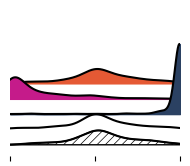

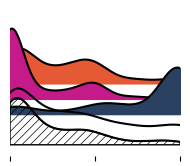

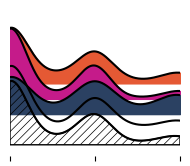

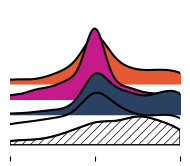

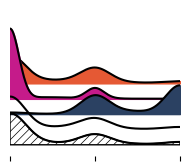

In [1110]:
for m, name in enumerate(model_names):
    context_dists = [all_generation_probabilities[i][m] for i in range(3)]
    null_dists = [all_null_gen_probabilities[i][m] for i in range(2)]
    
    fig_i, ax_i = joypy.joyplot(context_dists + null_dists,
                                color=['#E55934', '#C51B8A', '#2B4162', 'None', 'None'],
                                figsize=(2,2),
                                x_range=(0, 1)
                               )

    
    #fig_i.suptitle(name)
    ax_i[-1].set_xticks([0,0.5,1])
    ax_i[-1].set_xticklabels([])
    ax_i[-2].collections[0].set_hatch('////')
    ax_i[-2].collections[0].set_edgecolor('black')
    
    fig_i.savefig(FIGURES_DIR/"joy_plots"/f"{name}_0126.pdf")

## KL Divergence

In [1050]:
all_model_counts = []
for m, model in enumerate(winopron_results_05):
    model_counts = primed_completion_difference_counts(model,
                                                       max_index = max([x["index"] for x in model]))
    all_model_counts.append(model_counts)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:18<00:00,  9.81it/s]


In [1051]:
all_model_null_counts = []
for model in all_null:
    model_counts_null = primed_completion_difference_counts_null(model,
                                                                 max_index = max([x["index"] for x in model]))
    all_model_null_counts.append(model_counts_null)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 361/361 [00:11<00:00, 30.11it/s]


In [1052]:
all_model_null_divergences = []

for model, null in zip(all_model_counts, all_model_null_counts):
    model_null_kl = get_null_divergences(model, null)
    all_model_null_divergences.append(model_null_kl)

In [1053]:
avg_div = np.array([np.sum(m, axis=0)/m.shape[0] for m in all_model_null_divergences])
avg_div

array([[0.76407957, 0.92186076, 0.53168755, 0.55300218],
       [0.46714847, 1.86129361, 0.25305518, 0.22820179],
       [1.01232298, 1.86742437, 0.25574005, 0.25142375],
       [0.3219917 , 0.38276557, 0.55518242, 0.63539248],
       [0.70262879, 4.15046908, 0.19154229, 0.19961305]])

In [1054]:
col_labels = [r"$c_m$", r"$c_f$", r"$c_{null1}$", r"$c_{null2}$"]

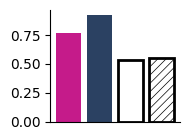

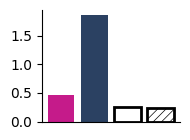

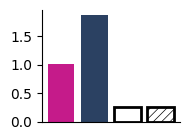

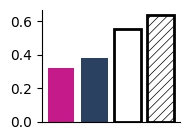

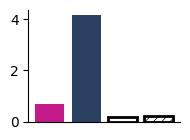

In [1112]:
bar_colors = ['#C51B8A', '#2B4162']
#os.mkdir(FIGURES_DIR/"divergences")
for row, model_name in zip(avg_div, model_names):
    fig_j, ax_j = plt.subplots(figsize=(2,1.5))
    ax_j.bar(col_labels[:2], row[:2], color=bar_colors[:2])
    ax_j.bar(col_labels[2:3], row[2:3], facecolor="None", edgecolor='black', linewidth=2)
    ax_j.bar(col_labels[3:], row[3:], facecolor="None", edgecolor='black', linewidth=2, hatch='////')
    ax_j.spines[['top', 'right']].set_visible(False)
    ax_j.set_xticks([])
    plt.tight_layout()
    fig_j.savefig(FIGURES_DIR/"divergences"/f"{model_name}_0226.pdf")

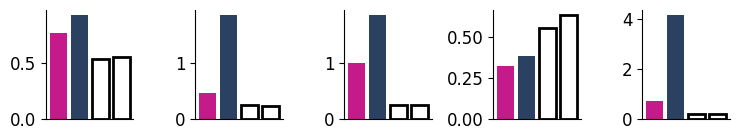

In [1056]:
bar_colors = ['#C51B8A', '#2B4162']

fig, axes = plt.subplots(1, len(model_names), figsize=(1.5 * len(model_names), 1.5))#, sharey=True)

for i, (row, model_name) in enumerate(zip(avg_div, model_names)):
    ax = axes[i]
    ax.bar(col_labels[:2], row[:2], color=bar_colors[:2])
    ax.bar(col_labels[2:], row[2:], facecolor="None", edgecolor='black', linewidth=2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks([])
    #ax.set_yticks([])
    ax.tick_params(axis='y', labelsize=12)
    #ax.set_title(model_name)

    #if i > 0:
        #ax.spines['left'].set_visible(False)
        #ax.tick_params(left=False)

plt.tight_layout()
# fig.savefig(FIGURES_DIR / "divergences" / "all_models_0226.pdf")
plt.show()

# Correlations with Cultural Biases

## Data Prep

In [69]:
raw_templates.head()

,occupation(0),other-participant(1),answer,pronoun_type,template,single_version
0,technician,customer,1,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $PARTICIPANT was told that $NOM_PRONOUN co...
1,technician,customer,0,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $OCCUPATION said that $NOM_PRONOUN had com...
2,technician,customer,1,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $PARTICIPANT received a call for $ACC_PRON...
3,technician,customer,0,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $OCCUPATION called for $ACC_PRONOUN to con...
4,technician,customer,1,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...,The $PARTICIPANT said that $POSS_PRONOUN fridg...


In [70]:
stereo.set_index('occupation', inplace=True, drop=True)
stereo.head()

,matched_role_from_appendix_b,english_mean
occupation,,
hygienist,dentalhygienists,0.57
worker,construction workers,0.19
clerk,clerks,0.42
officer,NaN,0.36
machinist,heavy equipment operators,0.15


In [71]:
# Now, taking the data from raw_templates and creating a DF with the index, missing role, pronoun type, stereotype, occupational or not
roles = []
role_types = []
for idx in raw_templates.index:
    answer = raw_templates["answer"][idx]
    if answer == 0:
        role = raw_templates["occupation(0)"][idx]
        role_type = "occupation"
    else:
        role = raw_templates["other-participant(1)"][idx]
        role_type = "participant"
        
    roles.append(role)
    role_types.append(role_type)
    

all_features = pd.DataFrame(data={"role": roles, "role_type": role_types})
all_features["stereotype"] = [stereo["english_mean"][role] for role in roles]
all_features["pronoun_type"] = raw_templates["pronoun_type"]
all_features["template"] = raw_templates["template"]
all_features.head()

,role,role_type,stereotype,pronoun_type,template
0,customer,participant,0.58,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
1,technician,occupation,0.35,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
2,customer,participant,0.58,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
3,technician,occupation,0.35,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
4,customer,participant,0.58,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...


In [72]:
all_features_wstereo = all_features[~np.isnan(all_features["stereotype"])]

In [73]:
print(f"Collected gender stereotypes for {len(all_features_wstereo)} out of {len(all_features)} sentences.")

Collected gender stereotypes for 279 out of 360 sentences.


## Testing Correlations

### Generation

#### Unprimed

In [912]:
unprimed_spearmans = []
unprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_gen_diffs[n][0]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans.append(corr)
    unprimed_pvals.append(p)

#### Male Primed

In [913]:
mprimed_spearmans = []
mprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n][0]):
        try:
            fem_probs.append(x[1][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans.append(corr)
    mprimed_pvals.append(p)

#### Female Primed

In [914]:
fprimed_spearmans = []
fprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n][0]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearmans.append(corr)
    fprimed_pvals.append(p)

#### Plotting 

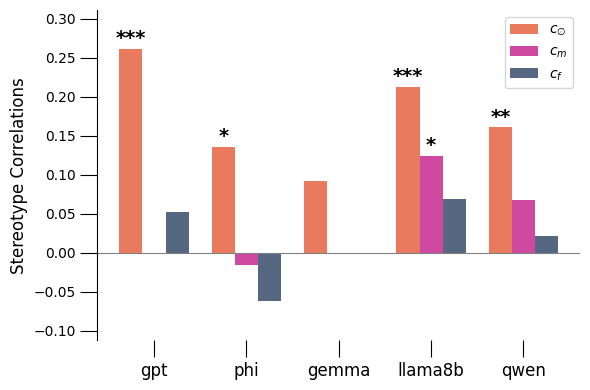

In [1084]:
# --- Plot setup ---
corr_colors = {
    'unprimed': '#E55934',   
    'mprimed':  '#C51B8A',
    'fprimed':  '#2B4162'   
}

x = np.arange(len(winopron_results_05))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width, unprimed_spearmans, width, label=r'$c_\emptyset$', color=corr_colors['unprimed'], alpha=0.8)
bars2 = ax.bar(x, mprimed_spearmans, width, label=r'$c_m$', color=corr_colors['mprimed'], alpha=0.8)
bars3 = ax.bar(x + width, fprimed_spearmans, width, label=r'$c_f$', color=corr_colors['fprimed'], alpha=0.8)

# --- Add significance asterisks ---
def annotate_significance(bars, pvals):
    for bar, p in zip(bars, pvals):
        height = bar.get_height()
        if p < 0.001:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '***',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '**',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '*',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )

min_height = min([min(unprimed_spearmans), min(mprimed_spearmans), min(fprimed_spearmans)])
max_height = max([max(unprimed_spearmans), max(mprimed_spearmans), max(fprimed_spearmans)])
            

annotate_significance(bars1, unprimed_pvals)
annotate_significance(bars2, mprimed_pvals)
annotate_significance(bars3, fprimed_pvals)

# --- Formatting ---
ax.set_ylabel(r'Stereotype Correlations', fontsize=12)
#ax.set_title('Spearman Correlations with Significance', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend()#ncol=3, loc='upper center')#loc='lower right')#bbox_to_anchor=(0,1), ncol=3)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylim(min_height - 0.05, max_height + 0.05)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.tick_params(size=12)


# Tidy layout
plt.tight_layout()
plt.savefig(REPORTS_DIR/"figures"/"spearman_correlations_0.5_models_no1b_newlabel.pdf")
plt.show()

#### Null Primed

In [ ]:
unprimed_spearmans = []
unprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_gen_diffs[n][0]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans.append(corr)
    unprimed_pvals.append(p)


# Mutual Information

In [96]:
unprimed_order = ["y_role_type", "y_stereo", "y_case", "y_order"]
primed_order = ["y_prime", "y_role_type", "y_stereo", "y_case", "y_order"]

unprimed_mi_dfs = []
primed_mi_dfs = []
for n, model in enumerate(winopron_results_05):
    unprimed_df = get_mi_df(model, all_features, include_primed=False, primed_status=False, prime=False)
    primed_df = get_mi_df(model, all_features, include_unprimed=False, primed_status=False)

    unprimed_df = unprimed_df[unprimed_order]
    primed_df = primed_df[primed_order]

    unprimed_mi_dfs.append(unprimed_df)
    primed_mi_dfs.append(primed_df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:45<00:00,  3.93it/s]


/tmp/ipykernel_3926487/2083545766.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[n, 0].set_xticklabels(unprimed_labels, rotation=90)
/tmp/ipykernel_3926487/2083545766.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[n, 1].set_xticklabels(primed_labels, rotation=90)


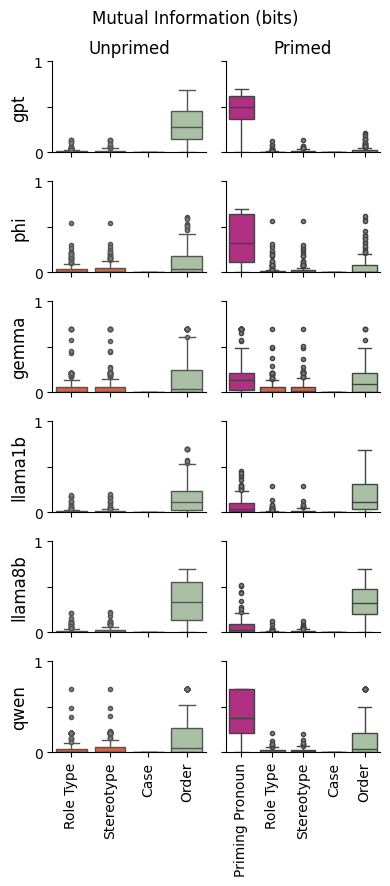

In [422]:
# Reorder the models, perhaps

fig, axs = plt.subplots(len(winopron_results_05), 2, sharey=True, figsize=(4, 9))

unprimed_labels = ["Role Type", "Stereotype", "Case", "Order"] # need to reorder so that order is last and groups hold
primed_labels = ["Priming Pronoun", "Role Type", "Stereotype", "Case", "Order"] # need to reorder so that ^^^ and priming is 1st

unprimed_colors = ["#E55934", "#E55934","#A7C4A0", "#A7C4A0"]
primed_colors   = ["#C51B8A", "#E55934", "#E55934","#A7C4A0", "#A7C4A0"]

for n, pair in enumerate(zip(unprimed_mi_dfs, primed_mi_dfs)):

    unprimed_df, primed_df = pair
    
    #sns.boxenplot(unprimed_df, ax=axs[n, 0], palette=unprimed_colors,
    #             flier_kws=dict(marker='o', s=10, linewidth=0, facecolor='gray'))
    #sns.boxenplot(primed_df, ax=axs[n, 1], palette=primed_colors,
    #             flier_kws=dict(marker='o', s=10, linewidth=0, facecolor='gray'))

    #sns.stripplot(unprimed_df, ax=axs[n, 0], size=3, palette=unprimed_colors)
    #sns.stripplot(primed_df, ax=axs[n, 1],size=3, palette=primed_colors)

    sns.boxplot(unprimed_df, ax=axs[n, 0], palette=unprimed_colors, 
                flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray'))
    sns.boxplot(primed_df, ax=axs[n, 1], palette=primed_colors,
               flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray'))

    #sns.barplot(unprimed_df.mean(axis=0), ax=axs[n, 0])
    #sns.barplot(primed_df.mean(axis=0), ax=axs[n, 1])

    axs[n, 1].set_yticklabels([])

    if n != len(winopron_results_05) - 1: 
        axs[n, 0].set_xticklabels([])
        axs[n, 1].set_xticklabels([])
    else:
        axs[n, 0].set_xticklabels(unprimed_labels, rotation=90)
        axs[n, 1].set_xticklabels(primed_labels, rotation=90)

    axs[n, 0].set_ylim(0,1)
    axs[n, 0].set_ylabel(model_names[n], fontsize=12)

    axs[n, 0].spines[['top', 'right']].set_visible(False)
    axs[n, 1].spines[['top', 'right']].set_visible(False)

axs[0, 0].set_yticks([0, 0.5, 1], [0, None, 1])
axs[0, 0].set_title("Unprimed")
axs[0, 1].set_title("Primed")

#fig.supylabel("Mutual Information (bits)")
fig.suptitle("Mutual Information (bits)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "MI_vertical_6models_box.pdf")

In [848]:
for df_i in unprimed_mi_dfs:
    print(f"Max: {df_i.y_stereo.max()}")
    print(f"Mean: {df_i.y_stereo.mean()}") 

Max: 0.1381245001261444
Mean: 0.013679525108989964
Max: 0.544820075882962
Mean: 0.04286217376952179
Max: 0.6956487430550645
Mean: 0.06944756990878481
Max: 0.19575150863779855
Mean: 0.015404121549259079
Max: 0.22159615225006357
Mean: 0.021898986813186874
Max: 0.6935640208376634
Mean: 0.05290109232173463


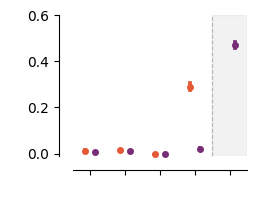

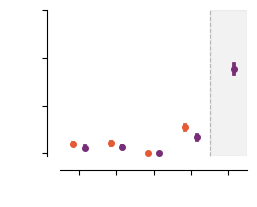

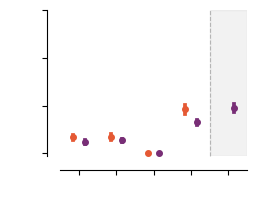

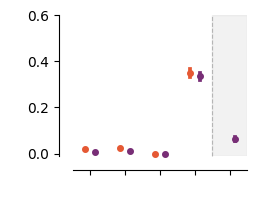

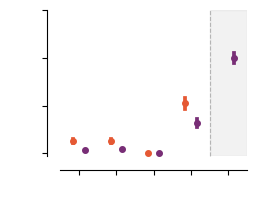

In [1083]:
unprimed_mi_dfs_no_1b = unprimed_mi_dfs[:3] + unprimed_mi_dfs[-2:]
primed_mi_dfs_no_1b = primed_mi_dfs[:3] + primed_mi_dfs[-2:]
for n, pair in enumerate(zip(unprimed_mi_dfs_no_1b, primed_mi_dfs_no_1b)):
    unprimed_df, primed_df = pair
    
    # Melt and combine
    unprimed_melted = unprimed_df.melt(var_name='feature', value_name='measurement')
    unprimed_melted['primed'] = 'unprimed'
    primed_melted = primed_df.melt(var_name='feature', value_name='measurement')
    primed_melted['primed'] = 'primed'
    combined_df = pd.concat([unprimed_melted, primed_melted], ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(2.5, 2))
    
    # Separation between first 4 features and the last
    ax.axvspan(3.5, 4.5, color='gray', alpha=0.1, zorder=0)
    ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Dodged pointplot using hue
    sns.pointplot(data=combined_df, x='feature', y='measurement',
                  hue='primed', hue_order=['unprimed', 'primed'],
                  palette={'unprimed': '#E55934', 'primed': '#782E76'},
                  linestyle='none', errorbar='se', markersize=3,
                  dodge=0.3, ax=ax)
    
    # No clipping
    ax.set_ylim(-.01, 0.6)
    ax.set_clip_on(False)
    for artist in ax.collections + ax.lines:
        artist.set_clip_on(False)
    
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines.bottom.set_position(('outward', 10))
    ax.spines.left.set_position(('outward', 10))
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend_.remove()  # remove auto-generated legend (or keep if you want)

    if n not in [0, 3]:
        ax.set_yticklabels([])
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_mi_plots" / f"{model_names[n]}.pdf",
                bbox_inches='tight')
    plt.show()

# Contextuality

In [98]:
# Create a raster/heatmap that diverges at 0 
# num_models x num_templates

In [921]:
# Are these calculations correct?
# Are they treating both directions at the same time?

def get_contextuality_table(
    model_measurements: list[dict],
    default_pronoun: int = 1,  # 0 for male, 1 for female
    max_index: int = 180
) -> pd.DataFrame:

    indices = []
    
    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []
    
    for idx in tqdm(range(max_index)):

        try:
            # Internal 
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')

        except Exception as e:
            logger.error(f"Error calculating internal mfirst degree of contextuality for index {idx}: {e}")
            mfirst_int_dc = np.nan
            

        try:
            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

        except Exception as e:
            logger.error(f"Error calculating internal ffirst degree of contextuality for index {idx}: {e}")
            ffirst_int_dc = np.nan
            

        try:
            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')

        except Exception as e:
            logger.error(f"Error calculating generation mfirst degree of contextuality for index {idx}: {e}")
            mfirst_gen_dc = np.nan
            

        try:
            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')

        except Exception as e:
            logger.error(f"Error calculating generation ffirst degree of contextuality for index {idx}: {e}")
            ffirst_gen_dc = np.nan
            

            

        

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df
        

In [922]:
contextualities = [get_contextuality_table(model) for model in winopron_results_05]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [02:11<00:00,  1.36it/s]


In [923]:
max_concat_arr = np.array(
    [df[['gen_mfirst','gen_ffirst']].max(axis=1) for df in contextualities]
)

In [924]:
context_or_arr = np.array(
    [((df['gen_mfirst'] > 0) | (df['gen_ffirst'] > 0))*1 for df in contextualities]
)

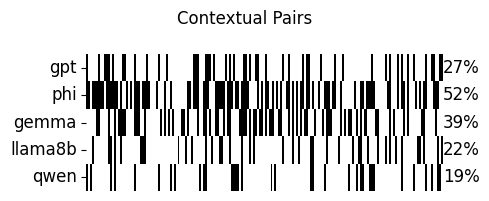

In [925]:
fig, ax = plt.subplots(figsize=(5, 2))
sns.heatmap(context_or_arr, 
            cbar=False, 
            xticklabels=False,
            yticklabels=model_names,
            cmap=ListedColormap(["#FFFFFF", "k"]), 
            center=0.5,
            ax=ax)#, square=True, )
# count nonzero cells per row
row_counts = (context_or_arr != 0).sum(axis=1)/180 * 100 

# add counts to the right of each row
n_cols = context_or_arr.shape[1]
for i, perc in enumerate(row_counts):
    ax.text(
        n_cols + 0.2,   # slightly to the right of the heatmap
        i + 0.5,        # center of the row
        str(round(perc))+"%",
        va="center",
        ha="left",
        fontsize=12
    )

ax.tick_params(labelsize=12)
fig.suptitle("Contextual Pairs")
plt.tight_layout()
#plt.savefig(FIGURES_DIR/"contextuality_barcode_6models.pdf")

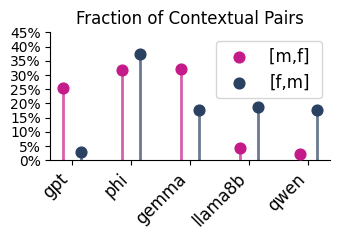

In [933]:
# Create a bar chart where for each model, there is one bar that counts the ANDs and one that counts the ORs
fig, ax = plt.subplots(figsize=(3.5,2.5))

mfirst_contextual_proportion = []
ffirst_contextual_proportion = []
for m, name in enumerate(model_names):
    mfirst, ffirst = np.sum(contextualities[m][['gen_mfirst','gen_ffirst']] > 0, axis=0)
    mfirst_contextual_proportion.append(mfirst/180 * 100)
    ffirst_contextual_proportion.append(ffirst/180 * 100)

x_lolli = np.arange(len(model_names))
offset = 0.15

# lollipop "sticks"
ax.vlines(
    x_lolli - offset,
    ymin=0,
    ymax=mfirst_contextual_proportion,
    color="#C51B8A",
    alpha=0.7,
    linewidth=2
)
ax.vlines(
    x_lolli + offset,
    ymin=0,
    ymax=ffirst_contextual_proportion,
    color="#2B4162",
    alpha=0.7,
    linewidth=2
)

# lollipop "candies"
ax.scatter(
    x_lolli - offset,
    mfirst_contextual_proportion,
    color="#C51B8A",
    s=60,
    label="[m,f] ",
    zorder=3
)
ax.scatter(
    x_lolli + offset,
    ffirst_contextual_proportion,
    color="#2B4162",
    s=60,
    label="[f,m]",
    zorder=3
)

# formatting
ax.set_xticks(x_lolli)
ax.set_xticklabels(model_names, fontsize=12, rotation=45, ha="right")
ax.set_ylim(0, 45)
ax.set_yticks(np.linspace(0, 45, 10), labels=[f"{int(i)}%" for i in np.linspace(0, 45, 10)])
ax.set_title("Fraction of Contextual Pairs", fontsize=12)
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR/"contextual_pair_fractions_no1b.pdf")

In [927]:
# Heatmap of model x model where the value is the number of overlapping contextuality mesaurements for the models
# i.e. how many instances that were contextual in at least one ordering in model 1 were contextual in at least one ordering in model 2

In [928]:
model_contextualities = pd.DataFrame()

for m, model_name in enumerate(model_names):
    model_contextualities[model_name] = (contextualities[m]['gen_mfirst'] > 0) | (contextualities[m]['gen_ffirst'] > 0)

model_contextualities

,gpt,phi,gemma,llama8b,qwen
0,True,True,False,False,True
1,False,True,False,False,False
2,False,False,False,False,True
3,False,True,False,True,False
4,False,True,False,False,False
...,...,...,...,...,...
175,True,True,False,False,False
176,False,True,True,False,False
177,False,True,False,True,True
178,True,False,False,False,True


In [931]:
cooccurrences = np.zeros((len(model_names), len(model_names)))

for int_pair, model_pair in zip(combinations(range(len(model_names)), 2), combinations(model_names, 2)):
    model_i, model_j = int_pair
    model1, model2 = model_pair
    count = (model_contextualities[model1] & model_contextualities[model2]).sum()
    cooccurrences[model_i, model_j] = count/model_contextualities[model1].sum()
    cooccurrences[model_j, model_i] = count/model_contextualities[model2].sum()

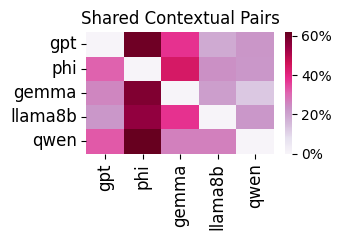

In [934]:
#heatmap_mask = cooccurrences.T == 0 

fig, ax = plt.subplots(figsize=(3.5,2.5))
hm = sns.heatmap(cooccurrences, cmap="PuRd", xticklabels=model_names, yticklabels=model_names, ax=ax, fmt=".0%")#,mask=heatmap_mask,)
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.tick_params(labelsize=12)
plt.title("Shared Contextual Pairs")
plt.tight_layout()
#ax.xaxis.tick_top()
#ax.xaxis.set_label_position('top')
#ax.yaxis.tick_right()
#ax.yaxis.set_label_position('right')
plt.savefig(FIGURES_DIR/"shared_contextual_heatmap_perc_no1b.pdf")

## Robustness Tests Varying Temperature

In [944]:
gpt03 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.3_wp_k40.ndjson")
max_gpt03 = max([x["index"] for x in gpt03])
f"{len(gpt03)} Measuremenents"

'724000 Measuremenents'

In [945]:
gpt07 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.7_wp_k40.ndjson")
max_gpt07 = max([x["index"] for x in gpt07])
f"{len(gpt07)} Measuremenents"

'724000 Measuremenents'

In [946]:
gpt_temps = [gpt03, gpt_wp, gpt07]

In [947]:
temp_gen_diffs = [primed_completion_differences(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs=True
                                              )
                 for d in gpt_temps]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:36<00:00,  4.95it/s]


In [948]:
temp_generation_probabilities = []
for n in range(3):
    temp_priming_probs = []
    for model,_ in temp_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        temp_priming_probs.append(fem_probs)
    temp_generation_probabilities.append(temp_priming_probs)


In [951]:
temp_names = ['GPT0.3', 'GPT0.5', 'GPT0.7']

In [959]:
len(temp_generation_probabilities)

3

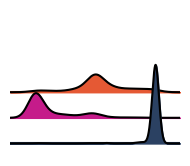

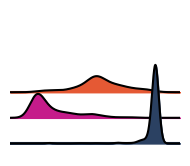

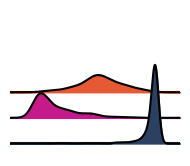

In [956]:
for m, name in enumerate(temp_names):
    context_dists = [temp_generation_probabilities[i][m] for i in range(3)]
    fig_i, ax_i = joypy.joyplot(context_dists,
                                color=['#E55934', '#C51B8A', '#2B4162'],
                                figsize=(2,2)
                               )
    ax_i[-1].set_xticks([])
    fig_i.savefig(FIGURES_DIR/"joy_plots"/f"{name}_0326.pdf")

In [969]:
unprimed_spearmans_temp = []
unprimed_pvals_temp = []

for n,model in enumerate(gpt_temps):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_gen_diffs[n][0]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans_temp.append(corr)
    unprimed_pvals_temp.append(p)

In [970]:
mprimed_spearmans_temp = []
mprimed_pvals_temp = []

for n,model in enumerate(gpt_temps):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n][0]):
        try:
            fem_probs.append(x[1][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans_temp.append(corr)
    mprimed_pvals_temp.append(p)

In [971]:
fprimed_spearmans_temp = []
fprimed_pvals_temp = []

for n,model in enumerate(gpt_temps):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n][0]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearmans_temp.append(corr)
    fprimed_pvals_temp.append(p)

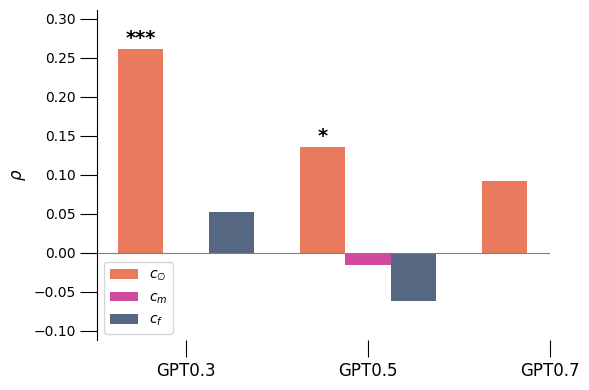

In [995]:
# --- Plot setup ---
corr_colors = {
    'unprimed': '#E55934',   
    'mprimed':  '#C51B8A',
    'fprimed':  '#2B4162'   
}

x = np.arange(len(gpt_temps))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width, unprimed_spearmans_temp, width, label=r'$c_\emptyset$', color=corr_colors['unprimed'], alpha=0.8)
bars2 = ax.bar(x, mprimed_spearmans_temp, width, label=r'$c_m$', color=corr_colors['mprimed'], alpha=0.8)
bars3 = ax.bar(x + width, fprimed_spearmans_temp, width, label=r'$c_f$', color=corr_colors['fprimed'], alpha=0.8)

# --- Add significance asterisks ---
def annotate_significance(bars, pvals):
    for bar, p in zip(bars, pvals):
        height = bar.get_height()
        if p < 0.001:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '***',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '**',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '*',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )

min_height = min([min(unprimed_spearmans_temp), min(mprimed_spearmans_temp), min(fprimed_spearmans_temp)])
max_height = max([max(unprimed_spearmans_temp), max(mprimed_spearmans_temp), max(fprimed_spearmans_temp)])
            

annotate_significance(bars1, unprimed_pvals_temp)
annotate_significance(bars2, mprimed_pvals_temp)
annotate_significance(bars3, fprimed_pvals_temp)

# --- Formatting ---
ax.set_ylabel(r'$\rho$', fontsize=12)
#ax.set_title('Spearman Correlations with Significance', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(temp_names, fontsize=12)
ax.legend()#ncol=3, loc='upper center')#loc='lower right')#bbox_to_anchor=(0,1), ncol=3)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylim(min_height - 0.05, max_height + 0.05)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.tick_params(size=12)


# Tidy layout
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"spearman_correlations_temps.pdf")
plt.show()

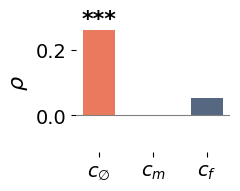

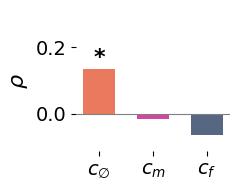

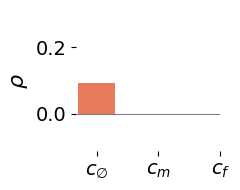

In [1007]:
corr_colors = {
    'unprimed': '#E55934',
    'mprimed':  '#C51B8A',
    'fprimed':  '#2B4162'
}

#os.mkdir(FIGURES_DIR / "spearman_correlations" )

labels = [r'$c_\emptyset$', r'$c_m$', r'$c_f$']
colors = [corr_colors['unprimed'], corr_colors['mprimed'], corr_colors['fprimed']]

all_vals = list(unprimed_spearmans_temp) + list(mprimed_spearmans_temp) + list(fprimed_spearmans_temp)
min_height = min(all_vals)
max_height = max(all_vals)

for i in range(len(gpt_temps)):
    fig, ax = plt.subplots(figsize=(2.5, 2))

    vals = [unprimed_spearmans_temp[i], mprimed_spearmans_temp[i], fprimed_spearmans_temp[i]]
    pvals = [unprimed_pvals_temp[i], mprimed_pvals_temp[i], fprimed_pvals_temp[i]]

    bars = ax.bar(np.arange(3), vals, color=colors, alpha=0.8, width=0.6)

    for bar, p in zip(bars, pvals):, 
        height = bar.get_height()
        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = None
        if star:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, star,
                ha='center', va='bottom',
                fontsize=16, fontweight='bold', color='black'
            )

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(labels, fontsize=14)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylim(min_height - 0.05, max_height + 0.05)
    ax.set_ylabel(r'$\rho$', fontsize=16)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "figures" / "spearman_correlations" / f"{temp_names[i]}.pdf")
    plt.show()

In [975]:
unprimed_mi_dfs_temp = []
primed_mi_dfs_temp = []
for n, model in enumerate(gpt_temps):
    unprimed_df = get_mi_df(model, all_features, include_primed=False, primed_status=False, prime=False)
    primed_df = get_mi_df(model, all_features, include_unprimed=False, primed_status=False)

    unprimed_df = unprimed_df[unprimed_order]
    primed_df = primed_df[primed_order]

    unprimed_mi_dfs_temp.append(unprimed_df)
    primed_mi_dfs_temp.append(primed_df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [01:11<00:00,  2.51it/s]


In [1058]:
2+2

4

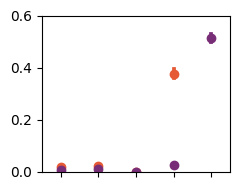

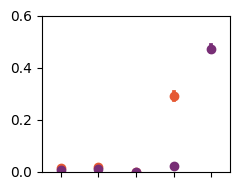

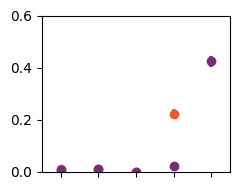

In [996]:
for n, pair in enumerate(zip(unprimed_mi_dfs_temp, primed_mi_dfs_temp)):
    unprimed_df, primed_df = pair
    
    # Melt and combine
    unprimed_melted = unprimed_df.melt(var_name='feature', value_name='measurement')
    unprimed_melted['primed'] = 'unprimed'
    primed_melted = primed_df.melt(var_name='feature', value_name='measurement')
    primed_melted['primed'] = 'primed'
    combined_df = pd.concat([unprimed_melted, primed_melted], ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(2.5, 2))
    
    # Separation between first 4 features and the last
    ax.axvspan(3.5, 4.5, color='gray', alpha=0.1, zorder=0)
    ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Dodged pointplot using hue
    sns.pointplot(data=combined_df, x='feature', y='measurement',
                  hue='primed', hue_order=['unprimed', 'primed'],
                  palette={'unprimed': '#E55934', 'primed': '#782E76'},
                  linestyle='none', errorbar='se', markersize=3,
                  dodge=0.3, ax=ax)
    
    # No clipping
    ax.set_ylim(-.01, 0.6)
    ax.set_clip_on(False)
    for artist in ax.collections + ax.lines:
        artist.set_clip_on(False)
    
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines.bottom.set_position(('outward', 10))
    ax.spines.left.set_position(('outward', 10))
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend_.remove()  # remove auto-generated legend (or keep if you want)

    if n not in [0, 3]:
        ax.set_yticklabels([])
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_mi_plots" / f"{temp_names[n]}.pdf",
                bbox_inches='tight')
    plt.show()

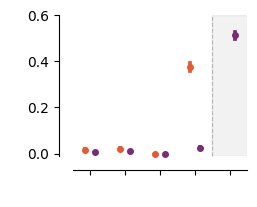

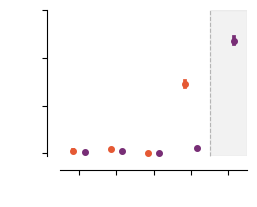

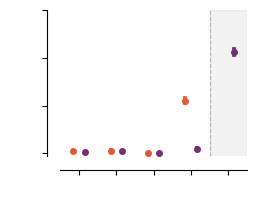

In [1115]:
for n, pair in enumerate(zip(unprimed_mi_dfs_temp, primed_mi_dfs_temp)):
    unprimed_df, primed_df = pair
    
    # Melt and combine
    unprimed_melted = unprimed_df.melt(var_name='feature', value_name='measurement')
    unprimed_melted['primed'] = 'unprimed'
    primed_melted = primed_df.melt(var_name='feature', value_name='measurement')
    primed_melted['primed'] = 'primed'
    combined_df = pd.concat([unprimed_melted, primed_melted], ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(2.5, 2))
    
    # Separation between first 4 features and the last
    ax.axvspan(3.5, 4.5, color='gray', alpha=0.1, zorder=0)
    ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Dodged pointplot using hue
    sns.pointplot(data=combined_df, x='feature', y='measurement',
                  hue='primed', hue_order=['unprimed', 'primed'],
                  palette={'unprimed': '#E55934', 'primed': '#782E76'},
                  linestyle='none', errorbar='se', markersize=3,
                  dodge=0.3, ax=ax)
    
    # No clipping
    ax.set_ylim(-.01, 0.6)
    ax.set_clip_on(False)
    for artist in ax.collections + ax.lines:
        artist.set_clip_on(False)
    
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines.bottom.set_position(('outward', 10))
    ax.spines.left.set_position(('outward', 10))
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend_.remove()  # remove auto-generated legend (or keep if you want)

    if n not in [0, 3]:
        ax.set_yticklabels([])
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_mi_plots" / f"{temp_names[n]}.pdf",
                bbox_inches='tight')
    plt.show()

In [ ]:
# clip_on=false  in these plots
# rotate labels
# look at priming work in LLMs

In [978]:
contextualities_temp = [get_contextuality_table(model) for model in gpt_temps]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [02:09<00:00,  1.39it/s]


In [979]:
mfirst_contextual_proportion_temp = []
ffirst_contextual_proportion_temp = []
for m, name in enumerate(temp_names):
    mfirst, ffirst = np.sum(contextualities_temp[m][['gen_mfirst','gen_ffirst']] > 0, axis=0)
    mfirst_contextual_proportion_temp.append(mfirst/180 * 100)
    ffirst_contextual_proportion_temp.append(ffirst/180 * 100)

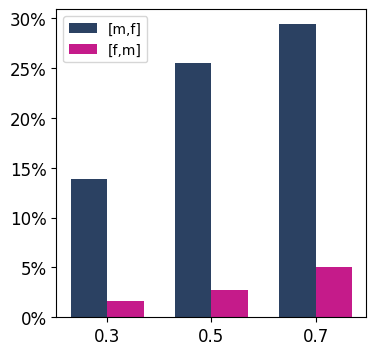

In [1013]:
fig, ax = plt.subplots(figsize=(4,4))

x = np.arange(len(temp_names))  # positions
width = 0.35                    # bar width

ax.bar(x - width/2, mfirst_contextual_proportion_temp, width, label='[m,f]', color="#2B4162")
ax.bar(x + width/2, ffirst_contextual_proportion_temp, width, label='[f,m]', color='#C51B8A')

ax.set_xticks(x, ["0.3", "0.5", "0.7"], fontsize=12)
ax.set_yticks(np.linspace(0, 30, 7), labels=[f"{int(i)}%" for i in np.linspace(0, 30, 7)], fontsize=12)
plt.legend()

plt.savefig(FIGURES_DIR/"gpt_temps_contextuality_counts.pdf")

In [984]:
model_contextualities_temp = pd.DataFrame()

for m, model_name in enumerate(temp_names):
    model_contextualities_temp[model_name] = (contextualities_temp[m]['gen_mfirst'] > 0) | (contextualities_temp[m]['gen_ffirst'] > 0)

model_contextualities_temp

,GPT0.3,GPT0.5,GPT0.7
0,True,True,True
1,False,False,False
2,False,False,False
3,False,False,True
4,False,False,False
...,...,...,...
175,True,True,True
176,True,False,True
177,False,False,True
178,True,True,True


In [985]:
cooccurrences_temp = np.zeros((len(temp_names), len(temp_names)))

for int_pair, model_pair in zip(combinations(range(len(temp_names)), 2), combinations(temp_names, 2)):
    model_i, model_j = int_pair
    model1, model2 = model_pair
    count = (model_contextualities_temp[model1] & model_contextualities_temp[model2]).sum()
    cooccurrences_temp[model_i, model_j] = count/model_contextualities_temp[model1].sum()
    cooccurrences_temp[model_j, model_i] = count/model_contextualities_temp[model2].sum()

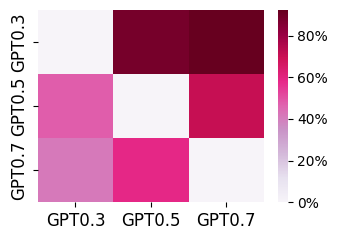

In [1004]:
#heatmap_mask = cooccurrences.T == 0 

fig, ax = plt.subplots(figsize=(3.5,2.5))
hm = sns.heatmap(cooccurrences_temp, cmap="PuRd", xticklabels=temp_names, yticklabels=temp_names, ax=ax, fmt=".0%")#,mask=heatmap_mask,)
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.tick_params(labelsize=12)
#plt.title("Shared Contextual Pairs")
plt.tight_layout()
#ax.xaxis.tick_top()
#ax.xaxis.set_label_position('top')
#ax.yaxis.tick_right()
#ax.yaxis.set_label_position('right')
plt.savefig(FIGURES_DIR/"shared_contextual_heatmap_temp.pdf")